# 1. Importing necessary libraries

In [64]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# 2. Business understanding and reading the data

Forecasting energy demand is an essential step in dispatching energy generators ensuring safety and cost optimisation.

While decisions to rebalance the grid are constantly taken, and changes happen within hours, having a reliable mid range horizon forecast of energy demand helps in planning ahead. This allows the search of solutions with a wider range of energy sources, consequently allowing for better rates

In [65]:
#Reading the dataset of consumption, generation and pricing.
df1 = pd.read_csv('/Users/arthurassis/Documents/CCT - Data Analytics for Business/Machine Learning/Semester 2/CA01-MachineLearning-Semester2/archive-3/energy_dataset.csv')

In [66]:
#Print the main information about the dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In this project we are interested in studying and forecasting the total load actual, based only in calendar and weather variables. Therefore, all the variable but **time**, **total load actual** and **total load forecast** will be dropped of our dataset.

In [67]:
#Defining the dataset that will be studyied

df2 = df1[['time', 'total load actual', 'total load forecast']]

In [68]:
#Printing the first 5 rows of df2
df2.head()

,time,total load actual,total load forecast
0,2015-01-01 00:00:00+01:00,25385.0,26118.0
1,2015-01-01 01:00:00+01:00,24382.0,24934.0
2,2015-01-01 02:00:00+01:00,22734.0,23515.0
3,2015-01-01 03:00:00+01:00,21286.0,22642.0
4,2015-01-01 04:00:00+01:00,20264.0,21785.0


In [69]:
#Printing the last 5 rows of df2
df2.tail()

,time,total load actual,total load forecast
35059,2018-12-31 19:00:00+01:00,30653.0,30619.0
35060,2018-12-31 20:00:00+01:00,29735.0,29932.0
35061,2018-12-31 21:00:00+01:00,28071.0,27903.0
35062,2018-12-31 22:00:00+01:00,25801.0,25450.0
35063,2018-12-31 23:00:00+01:00,24455.0,24424.0


# 3. Data Cleaning and Preparation

## 3.1. Removing Offset from the timestamp

Time in the dataset is read as an object, and it has an offset that has to be studied. The offset will be split from the main time, so that we can understand what exactly it meas.

In [70]:
#Splitting the UTC Offset from the main time. We use the '+' sign to split the string
df2['Time'] = df2['time'].str.split('+', expand=True)[0]
df2['UTC Offset'] = df2['time'].str.split('+', expand=True)[1]

In [71]:
#Verifying the unique values of the column Offset
df2['UTC Offset'].unique()

array(['01:00', '02:00'], dtype=object)

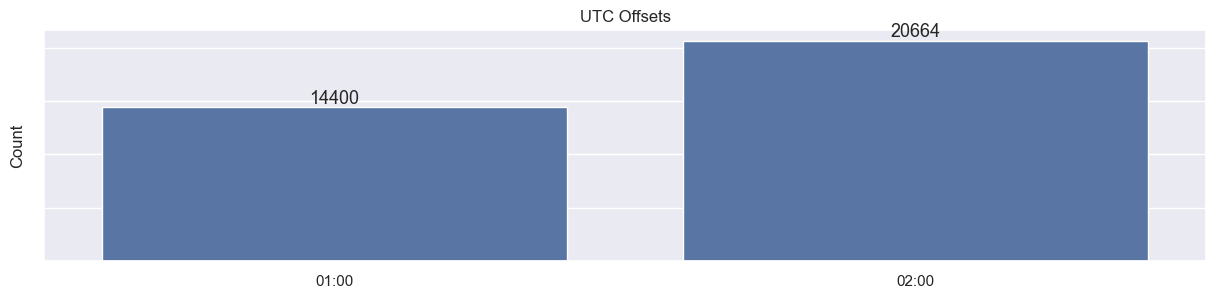

In [72]:
#Plotting a bar chart with the amount of each UTC Offset
sns.set(rc={"figure.figsize":(15, 3)})
f, axes = plt.subplots()
ax1 = sns.countplot(data=df2, x='UTC Offset')
ax1.set(title = 'UTC Offsets')
ax1.set_xlabel('', fontsize = 12)
ax1.set_ylabel('Count', fontsize = 12)
ax1.set(yticklabels=[]);
ax1.bar_label(ax1.containers[0], fmt='%.f', fontsize=13);

The Time columns will be converted into a timestamp. This will also allow to analyse the timestamps of UTC Offsets.

In [73]:
#Converting the string of column 'Time' into a time serie

df2['DateTime'] = pd.to_datetime(df2['Time'], format='%Y-%m-%d %H:%M:%S')

It will be verified in which timestamps the UTC Offsets change.

In [74]:
#Marking the transitions using a shift function. The shift function is used to compare the current value with the
#next value in the dataset

#Shifting the column UTC Offset and comparing to the original value, every time there is a change, my transition_mark marks True
transition_mask = df2['UTC Offset'] != df2['UTC Offset'].shift(1)

transition_times = df2.loc[transition_mask, ['DateTime', 'UTC Offset']]
print(transition_times)

                 DateTime UTC Offset
0     2015-01-01 00:00:00      01:00
2090  2015-03-29 03:00:00      02:00
7130  2015-10-25 02:00:00      01:00
10826 2016-03-27 03:00:00      02:00
16034 2016-10-30 02:00:00      01:00
19562 2017-03-26 03:00:00      02:00
24770 2017-10-29 02:00:00      01:00
28298 2018-03-25 03:00:00      02:00
33506 2018-10-28 02:00:00      01:00


The first line will be ignored, because the first row receives 0 when shifted forward. All the transition happen on the end of march and end of october. The changes in UTC represent the changes for summer time and back to regular time, as they match exactly the dates of these transition in Spain from 2015 until 2018. 

The target variable is expected to be stongly influenced by the local time, once it captures properly local behaviour, such as time people go to work, have dinner and go to sleep. Therefore, UTC Offset can be completely ignored, this way the analysis is carried considering local time.

In [75]:
#Printing the columns available on the dataset

df2.columns

Index(['time', 'total load actual', 'total load forecast', 'Time',
       'UTC Offset', 'DateTime'],
      dtype='object')

All the columns apart from the target variable and the local DateTime will be dropped.

## 3.2. Verifying frequency, regularity, duplicated and null values

In [76]:
#Defining df2 with only its chosen columns

df2 = df2[['DateTime', 'total load actual', 'total load forecast']]

In [77]:
#Checking the frenquency of data

freq = pd.infer_freq(df2['DateTime'])
print(freq)

None


In [78]:
# Checking the unique values of the difference between two subsequent timestamps
(df2['DateTime'] - df2['DateTime'].shift(1)).unique()

<TimedeltaArray>
[NaT, '0 days 01:00:00', '0 days 02:00:00', '0 days 00:00:00']
Length: 4, dtype: timedelta64[ns]

In [79]:
# Checking the amount of unique values between two subsequent timestamps
(df2['DateTime'] - df2['DateTime'].shift(1)).value_counts()

DateTime
0 days 01:00:00    35055
0 days 02:00:00        4
0 days 00:00:00        4
Name: count, dtype: int64

The data's granularity is hourly, once the timestamp does not contain difference of minutes or seconds. However, the time is not regularly divided. Although most of the shifts are 1 entire hour, there are shifts of 2 hours and duplicated timestamps. This happens because of the shift of time to summer time. When the country enters in summer time watches are adjusted 1 hour forward, creating a gap of 2 hours, and when returning the normal time, watches are adjusted 1 hours backward, creating a gap of 0 hours.

As there are very few records with this pattern compared to the size of the data, the duplicated records will simply be discarded, and the gaps will be filled with a linear interpolation of the values. To do it so, a regular time series matching the same range of the dataset will be created and joined to the dataset, and the nulls generated on the process will be filled.

In [80]:
#Dropping duplicated timestamps
df2.drop_duplicates(subset = 'DateTime', inplace = True)

In [81]:
#Create a timestamp with regular 1H intervals

start_date = df2['DateTime'].min()
finish_date = df2['DateTime'].max()
date_range = pd.date_range(start=start_date, end=finish_date, freq='1H')

In [82]:
#Defining the new data_range created as the index of df2

df2 = df2.set_index('DateTime').reindex(date_range)

In [83]:
#Reseting df2's index in order to work with integer index

df2.reset_index(inplace = True)
df2.rename(columns = {'index': 'timestamp'}, inplace = True)

In [84]:
#Checking the frenquency of data

freq = pd.infer_freq(df2['timestamp'])
print(freq)

h


It is confirmed that the data has been regularised for hourly periods.

In [85]:
#Checking for null values

df2.isna().sum()

timestamp               0
total load actual      40
total load forecast     4
dtype: int64

In [86]:
#Verifying if null values are consecutive

null_mask = df2['total load actual'].isna()
one_hour_count = (df2.loc[null_mask]['timestamp'] - df2.loc[null_mask]['timestamp'].shift(1)).value_counts()
one_hour_count[one_hour_count > 1]

timestamp
0 days 01:00:00    14
0 days 03:00:00     2
Name: count, dtype: int64

There are only 14 consecutives null values out of the 40 total null values, and yet, they might be consecutive by a unit difference. Considering this represents less the 0.05% of the dataset, the values will be inputed using a linear interpolation.

In [87]:
#Fill the null values with a linear interpolation

df2 = df2.interpolate(method='linear', limit_direction='both')

In [88]:
#Verifying nulls in the dataframe

df2.isna().sum()

timestamp              0
total load actual      0
total load forecast    0
dtype: int64

In [90]:
df2.to_csv('part_1_output_clean_data.csv', index = False)

New features that allow a easier visualisation of the dataset will added to it.